<a href="https://colab.research.google.com/github/akkuraina/student-pass-fail-prediction/blob/main/mlaMiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

# Generate random data
study_hours = np.random.randint(1, 10, 100)
attendance = np.random.randint(50, 100, 100)

# Non-linear rule + noise
result = []
for h, a in zip(study_hours, attendance):
    score = h * 0.6 + a * 0.04 + np.random.randn() * 0.5
    if score > 5:
        result.append(1)
    else:
        result.append(0)

# Create DataFrame
df = pd.DataFrame({
    "Study Hours": study_hours,
    "Attendance": attendance,
    "Result": result
})

print(df.head())

   Study Hours  Attendance  Result
0            7          84       1
1            4          86       1
2            8          96       1
3            5          63       1
4            7          52       1


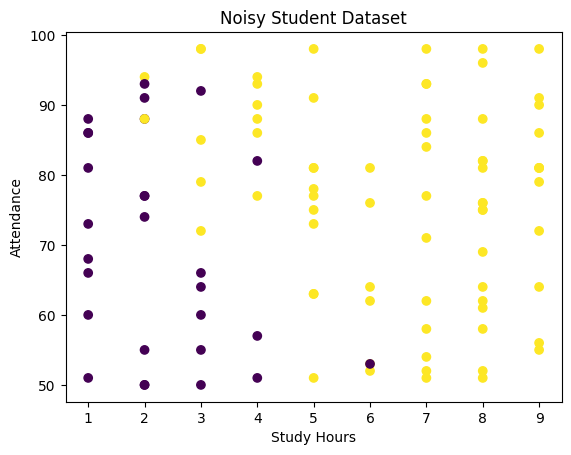

In [ ]:
plt.scatter(df["Study Hours"], df["Attendance"], c=df["Result"])
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Noisy Student Dataset")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Study Hours", "Attendance"]].values
y = df["Result"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("k-NN Accuracy:", accuracy_score(y_test, y_pred_knn))

k-NN Accuracy: 0.9


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=4)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8666666666666667


In [ ]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8333333333333334


In [ ]:
print("\nFinal Comparison:")
print("-------------------")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("k-NN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))


Final Comparison:
-------------------
Logistic Regression: 0.9
k-NN: 0.9
Decision Tree: 0.8666666666666667
Naive Bayes: 0.8333333333333334
